# P4: Hill Climbing

**FIT1061 Introduction to Artificial Intelligence — Week 4**

Sometimes the search space is too large to explore systematically. Hill climbing takes a different approach: start somewhere, look at your neighbours, and always move to the best one. It's fast, simple, and often gets stuck. In December 2022, Southwest Airlines' scheduling system collapsed — a reminder of what happens when optimisation algorithms fail at scale.

**This notebook covers P4.1 (hill climbing for 8-queens).**

> **🗣 Milestone task.** P4 requires a tutor discussion for sign-off. After completing all parts (including the reflection), book a discussion with your tutor.

> **P4.1 is personalised by your Monash student ID** — see the 'Your personalised instance' section below.


---

## Setup

Run the cell below to import the helper functions. These are defined in `p4_helpers.py` (in the same folder as this notebook). **You do not need to modify `p4_helpers.py`.**

In [43]:
from p4_helpers import (random_board, count_violations, get_neighbours,
                        visualise_board, plot_violations, plot_multiple_runs)
import random
print("Imports OK.")

Imports OK.


---

## Warm-up: the example from the whiteboard

In the lecture we traced **one step of hill climbing** on the 4-queens board below. Work through
it yourself to warm up, then do your own (8-queens) board in Part 0.

Stuck? This is the exact example we worked through in the lecture; revisit the slides or the workshop.

**Starting board** `[1, 2, 1, 3]` (each number is the 0-indexed column of the queen in that row,
one queen per row). **3 violations**:

```
      c0 c1 c2 c3
row0   .  Q  .  .
row1   .  .  Q  .
row2   .  Q  .  .
row3   .  .  .  Q
```

The 3 attacking pairs: rows 0 & 2 share column 1; rows 0 & 1 attack on a diagonal; rows 1 & 2
attack on a diagonal.

A neighbour = move one queen within its row (4 rows x 3 other columns = **12 neighbours**).
Fill in the **Violations** column by hand, then answer below:

| Move | New state | Violations | Better than 3? |
|---|---|---|---|
| r0: 1->0 | `[0,2,1,3]` | ? | |
| r0: 1->2 | `[2,2,1,3]` | ? | |
| r0: 1->3 | `[3,2,1,3]` | ? | |
| r1: 2->0 | `[1,0,1,3]` | ? | |
| r1: 2->1 | `[1,1,1,3]` | ? | |
| r1: 2->3 | `[1,3,1,3]` | ? | |
| r2: 1->0 | `[1,2,0,3]` | ? | |
| r2: 1->2 | `[1,2,2,3]` | ? | |
| r2: 1->3 | `[1,2,3,3]` | ? | |
| r3: 3->0 | `[1,2,1,0]` | ? | |
| r3: 3->1 | `[1,2,1,1]` | ? | |
| r3: 3->2 | `[1,2,1,2]` | ? | |

1. Which neighbour has the **fewest** violations?
2. Would hill climbing move there? What is the **new** violation count?

*(This board is 4-queens: small enough to trace fully. Part 0 below is on YOUR 8-queens board.)*


---

## Your personalised instance (P4.1)

Hill climbing's update rule is **personalised** for this task. Each student gets:

- A different 8-queens **starting board**.
- A different set of **4 candidate neighbours** (out of the 56 possible single-queen moves).

You will hand-trace ONE hill-climbing step on YOUR instance before writing any code. The full algorithm is your job in P4.1.

**Set your Monash student ID below**, then run the next two cells. Do not edit `task_instances.py`.


In [44]:
# Replace the placeholder with your Monash student ID (8 digits).
STUDENT_ID = "37524720"

assert STUDENT_ID.isdigit() and len(STUDENT_ID) == 8, (
    "Set STUDENT_ID to your 8-digit Monash student ID (digits only, in quotes)."
)


In [45]:
# Integrity check + instance generation.
# DO NOT EDIT task_instances.py — your tutor regenerates from your ID
# and compares fingerprints. Modifications will be caught.

from task_instances import generate_instance
from task_instances_lib import fingerprint

instance = generate_instance(STUDENT_ID)
board_inst = instance["board"]

print(f"Student ID:                {STUDENT_ID}")
print(f"task_instances.py SHA-256: {fingerprint('task_instances.py')}")
print()
print(board_inst.describe().split('  violations')[0].rstrip())  # board, no violation count yet


Student ID:                37524720
task_instances.py SHA-256: 1c5d5e8f79f8155d0b16e6a81f17fae3cee1bce7a5e1aa3d4344bbbe3d0e3c1f

Personalised starting board for student 37524720
  board      = [2, 5, 6, 3, 6, 7, 5, 2]


---

## Part 0: Hand-trace one hill-climbing step (P4.1)

**Before coding**, do ONE step of hill climbing on YOUR starting board by hand.

Hill climbing's rule: at each step, look at all neighbours and move to the one with the **fewest violations**. If no neighbour is strictly better, stop (local minimum).

Run the cell below to render YOUR starting board and your 4 candidate neighbours.

> **Why only 4 candidates?** The 8-queens problem has 56 neighbours per step (8 rows × 7 alternate columns). Tracing all of them by hand is busy-work. You'll trace 4 to understand the update rule, then implement the full algorithm in P4.1.


YOUR starting board: [2, 5, 6, 3, 6, 7, 5, 2]
YOUR initial violations: 8

YOUR 4 candidate neighbours (do NOT compute violations yet — that's your job):
  cand[0] = [2, 5, 6, 5, 6, 7, 5, 2]
  cand[1] = [2, 7, 6, 3, 6, 7, 5, 2]
  cand[2] = [2, 5, 6, 3, 6, 7, 7, 2]
  cand[3] = [1, 5, 6, 3, 6, 7, 5, 2]


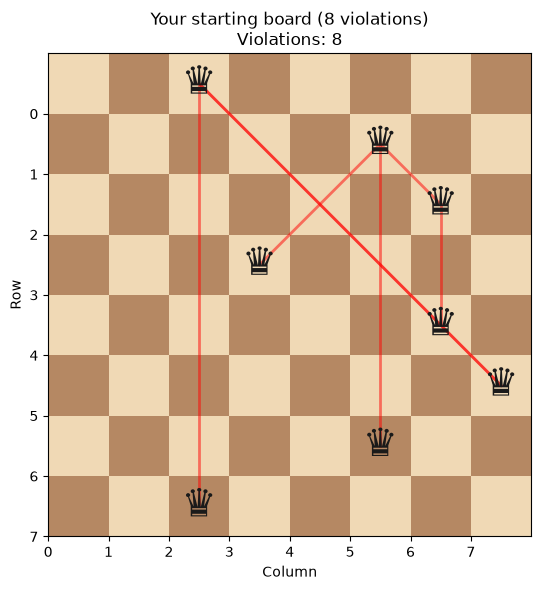

In [46]:
from p4_helpers import visualise_board, count_violations

initial_violations = count_violations(board_inst.board)
print(f"YOUR starting board: {board_inst.board}")
print(f"YOUR initial violations: {initial_violations}")
print()
print("YOUR 4 candidate neighbours (do NOT compute violations yet — that's your job):")
for i, cand in enumerate(board_inst.candidates):
    print(f"  cand[{i}] = {cand}")

# Render the starting board.
visualise_board(board_inst.board, title=f"Your starting board ({initial_violations} violations)")


---

### Articulation (P4.1, graded with the photo)

By hand, **count the violations** for each of your 4 candidate neighbours (use the same rule as `count_violations`: pairs of queens attacking each other on row, column, or diagonal). Then answer:

1. List the violation count for each candidate (`cand[0]`, `cand[1]`, `cand[2]`, `cand[3]`).
2. Which candidate has the **fewest** violations? (If there's a tie, list both.)
3. Would hill climbing move to that candidate? Why or why not? (Compare to your initial violation count.)
4. If hill climbing moves to your best candidate, what would the NEW violation count be?
5. Photograph your hand-counted violations (mark up the boards on paper).

Write your answers in the cell below.


In [47]:
# Articulation answers — type your responses here.
# Reference YOUR candidates printed above. Be specific.

answers = {
    "candidate_violations": [13,7,8,5],    # list of 4 ints, e.g. [5, 9, 4, 1]
    "best_candidate_index": [3],    # int in [0, 3]
    "best_candidate_violations": 5, # int
    "would_move?": True,             # True or False
    "new_violation_count_if_move": 5, # int (= best_candidate_violations if moving)
}

# Brief explanation (2-3 sentences) — does hill climbing make progress on YOUR
# board, or is it already at a local minimum? Reference YOUR numbers:
explanation = """
It counts the candidate boards for their violations, and choose the smallest violation board, and check if it is smaller than initial board, if it is smaller then it will become the next initial board
"""

# Sanity checks (only verify the cell is filled, not correctness).
for k, v in answers.items():
    assert v is not None, f"answers['{k}'] is still None"
assert explanation.strip() != "TYPE YOUR EXPLANATION HERE.", "Write your explanation."
print("Filled in. Photograph hand-counted boards + this cell for P4.1.")


Filled in. Photograph hand-counted boards + this cell for P4.1.


---

## Part 0: Understanding the 8-queens problem

### What is a queen?

In chess, a **queen** is the most powerful piece. It can move any number of squares in any direction: horizontally, vertically, or diagonally. Two queens **attack** each other if one could reach the other in a single move: that is, if they share the same row, column, or diagonal.

```
  . . . . . . . .      A queen (♛) attacks every square
  . . . . . . . .      marked with ×:
  . × . . . × . .
  . . × . × . . .      - Same row (horizontal)
  . . . ♛ . . . .      - Same column (vertical)
  . . × . × . . .      - Both diagonals
  . × . . . × . .
  . . . . . . × .
```

### The 8-queens problem

Place 8 queens on an 8×8 board so that **no two queens attack each other**. That means: no two queens can share the same row, column, or diagonal.

This is harder than it sounds: there are over 4 billion ways to place 8 queens on a board, but only **92** of them are solutions.

### Board representation

We represent a board as a **list of 8 integers**, where `board[row]` is the column of the queen in that row. Since there's exactly one queen per row, we only need to worry about **column conflicts** (two queens in the same column) and **diagonal conflicts** (two queens on the same diagonal).

```
board = [0, 4, 7, 5, 2, 6, 1, 3]

     0  1  2  3  4  5  6  7
  0  ♛  .  .  .  .  .  .  .    board[0] = 0
  1  .  .  .  .  ♛  .  .  .    board[1] = 4
  2  .  .  .  .  .  .  .  ♛    board[2] = 7
  3  .  .  .  .  .  ♛  .  .    board[3] = 5
  4  .  .  ♛  .  .  .  .  .    board[4] = 2
  5  .  .  .  .  .  .  ♛  .    board[5] = 6
  6  .  ♛  .  .  .  .  .  .    board[6] = 1
  7  .  .  .  ♛  .  .  .  .    board[7] = 3
```

This particular board happens to be a **solution** (no two queens attack each other, 0 violations). Let's see what a random board looks like.

Board: [6, 4, 7, 0, 1, 6, 0, 4]
Violations: 9


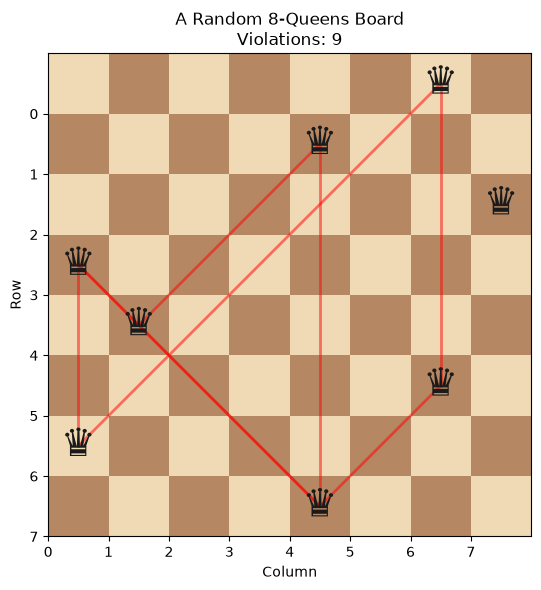

In [48]:
# Generate and visualise a random board
board = random_board()
print(f"Board: {board}")
print(f"Violations: {count_violations(board)}")
visualise_board(board, title="A Random 8-Queens Board")

The red lines show pairs of queens that attack each other. The number of violations is our **objective function**: the quantity we're trying to minimise. When violations = 0, we've solved the problem.

### How does hill climbing compare to BFS and greedy?

| | BFS (P2) | Greedy Best-First (P3) | Hill Climbing (P4) |
|---|---|---|---|
| **Goal** | Find shortest path | Find a path quickly | Minimise an objective function |
| **Data structure** | Queue | Priority queue | None (just "current state") |
| **Explores** | All reachable states, layer by layer | States near the goal | Only neighbours of current state |
| **Guarantee** | Shortest path | Finds a path (if one exists) | Local minimum only |

Hill climbing is fundamentally different: it doesn't search for a *path*, it searches for a *state* with the lowest objective value.

---

## Part 1: Explore the helper functions

Before implementing hill climbing, let's understand the tools you have.

### 1a: Counting violations

`count_violations(board)` counts the number of **pairs** of queens attacking each other. Two queens attack if they share a column or a diagonal. (Row conflicts are impossible in our representation.)

Run the cell below to see how violations change when you move a queen.

All in column 0: 28 violations
Known solution:  0 violations


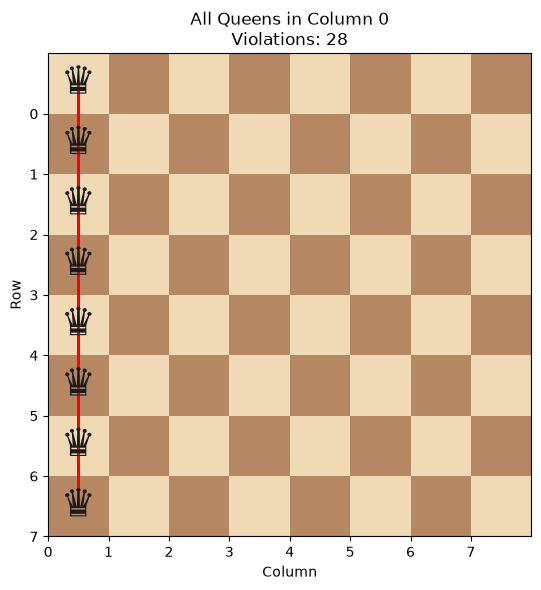

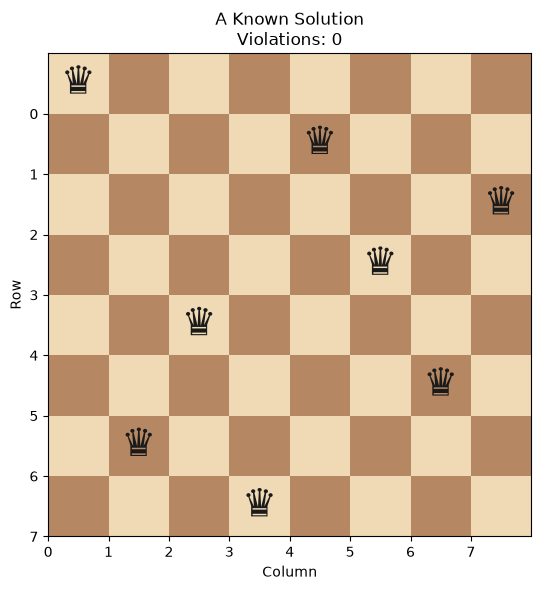

In [49]:
# A board with obvious conflicts
bad_board = [0, 0, 0, 0, 0, 0, 0, 0]  # All queens in column 0!
print(f"All in column 0: {count_violations(bad_board)} violations")

# A known solution
solution = [0, 4, 7, 5, 2, 6, 1, 3]
print(f"Known solution:  {count_violations(solution)} violations")

# Visualise both
visualise_board(bad_board, title="All Queens in Column 0")
visualise_board(solution, title="A Known Solution")

### 1b: Generating neighbours

A **neighbour** is any board you can reach by moving **one queen** to a different column within its row. For 8-queens, each queen has 7 possible moves (any other column), so there are 8 × 7 = **56 neighbours** for any board.

Run the cell below to see how neighbours work.

Board: [0, 2, 5, 2, 7, 0, 2, 7]
Current violations: 8
Number of neighbours: 56


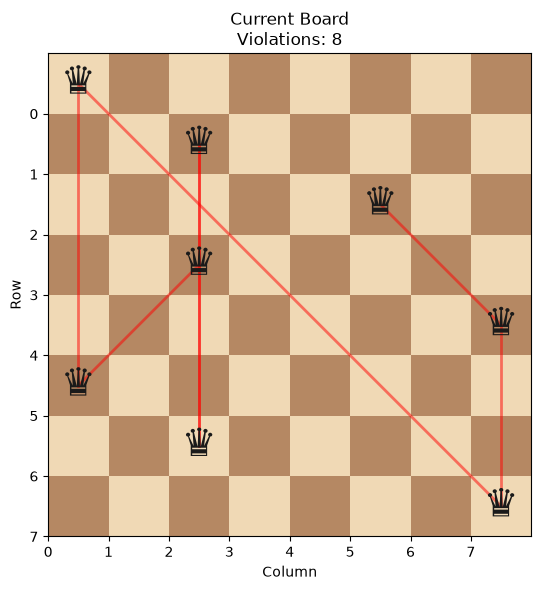


Example neighbour: move queen in row 0 to column 1
Violations: 8 → 7 (better!)


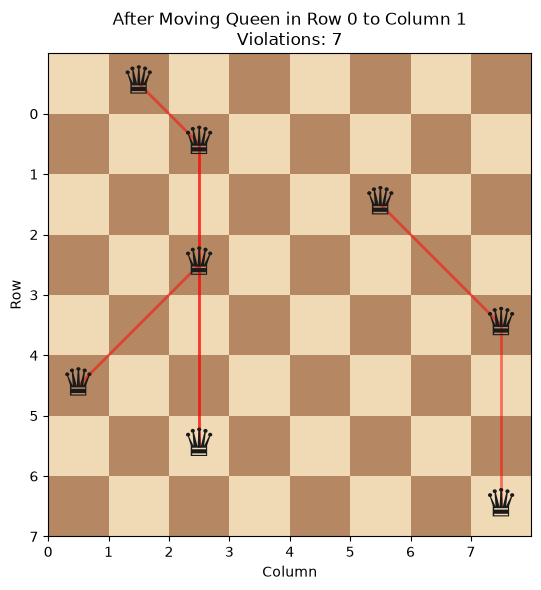

In [50]:
board = random_board()
neighbours = get_neighbours(board)
current_v = count_violations(board)
print(f"Board: {board}")
print(f"Current violations: {current_v}")
print(f"Number of neighbours: {len(neighbours)}")

visualise_board(board, title="Current Board")

# Show a neighbour: move the first queen to a different column
example_nb, ex_row, ex_col = neighbours[0]
ex_v = count_violations(example_nb)
print(f"\nExample neighbour: move queen in row {ex_row} to column {ex_col}")
print(f"Violations: {current_v} → {ex_v} ({'better!' if ex_v < current_v else 'worse' if ex_v > current_v else 'same'})")

visualise_board(example_nb, title=f"After Moving Queen in Row {ex_row} to Column {ex_col}")

### 1c: Finding the best neighbour

Hill climbing works by always moving to the **best** neighbour (the one with the fewest violations). Run the cell below to find the best neighbour for a given board.

Current board: [3, 3, 3, 7, 5, 0, 2, 6]
Current violations: 5


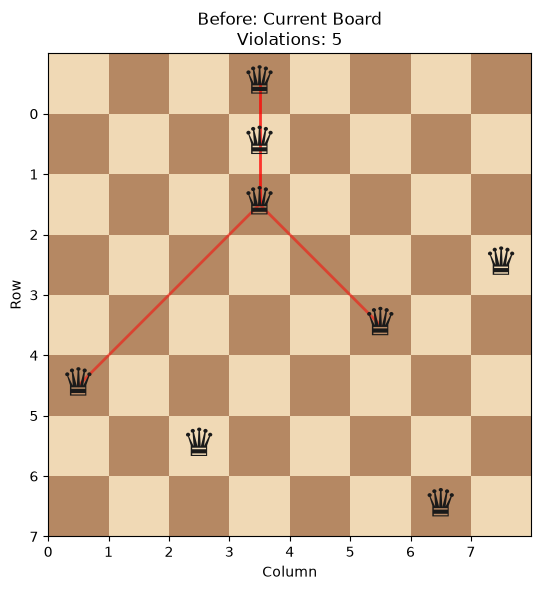


Best neighbour: [3, 3, 0, 7, 5, 0, 2, 6]
Best violations: 2 (improved by 3)


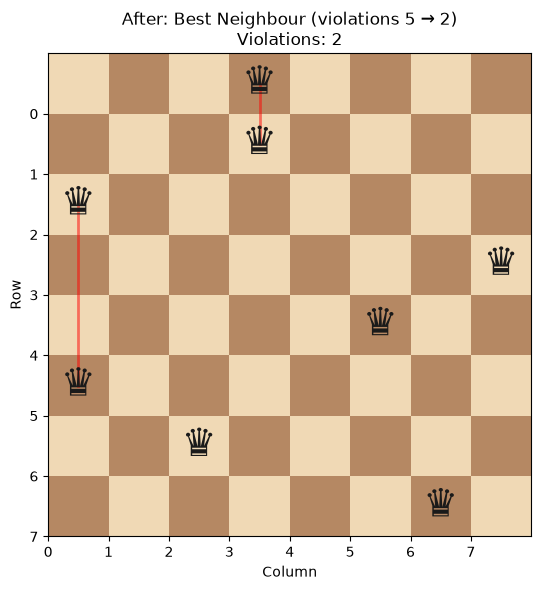

In [51]:
board = random_board()
current_v = count_violations(board)
print(f"Current board: {board}")
print(f"Current violations: {current_v}")

visualise_board(board, title="Before: Current Board")

# Find the best neighbour
best_board = None
best_v = current_v  # We only want to move if it's strictly better

for new_board, row, col in get_neighbours(board):
    v = count_violations(new_board)
    if v < best_v:
        best_v = v
        best_board = new_board

if best_board is not None:
    print(f"\nBest neighbour: {best_board}")
    print(f"Best violations: {best_v} (improved by {current_v - best_v})")
    visualise_board(best_board, title=f"After: Best Neighbour (violations {current_v} → {best_v})")
else:
    print(f"\nNo better neighbour found — we're at a local minimum!")

**Key insight:** The cell above does **one step** of hill climbing: find the best neighbour and check if it's better. Your job in Part 2 is to put this in a **loop** that keeps going until no improvement is possible.

---

## Part 2: Implement hill climbing (P4.1)

Now implement the full hill climbing algorithm. The structure:

```
Start with a random board
Loop:
    1. Count violations for current board
    2. Generate all neighbours
    3. Find the neighbour with the fewest violations
    4. If that neighbour is better → move to it
    5. If no neighbour is better → STOP (local minimum)
```

**Your job:** Complete the loop inside `hill_climbing()`. You need to:
1. Find the best neighbour (fewest violations).
2. Check if it's strictly better than the current board.
3. If yes, update the board. If no, stop.

In [52]:
def hill_climbing(board, max_steps=1000):
    """Run hill climbing on an 8-queens board.

    At each step, move to the neighbour with the fewest violations.
    Stop when no neighbour is better (local minimum) or max_steps reached.

    Args:
        board: Initial board (list of column positions, one per row).
        max_steps: Maximum number of iterations (safety limit).

    Returns:
        final_board: The board when the algorithm stopped.
        violations_log: List of violation counts, one per iteration.
    """
    current = list(board)  # Make a copy
    violations_log = []

    for step in range(max_steps):
        current_v = count_violations(current)
        violations_log.append(current_v)

        # If solved, stop
        if current_v == 0:
            break

        # --- YOUR CODE HERE ---
        # 1. Find the best neighbour (lowest violations).
        #    Hint: loop through get_neighbours(current), track the
        #    neighbour with the fewest violations.
        neighbours = get_neighbours(current)
        current_v = count_violations(current)
        best_board = None
        best_v = current_v
        for new_board,row, col in get_neighbours(current):
            v = count_violations(new_board)
            if v < best_v:
                best_v = v
                best_board = new_board
                violations_log.append(v)
        
        #
        # 2. If the best neighbour has fewer violations than current,
        #    update current to be that neighbour.
        #
        # 3. If no neighbour is better, break (local minimum).
        if best_board is None:
            break
        current= best_board

        # --- END YOUR CODE ---

    return current, violations_log

### Hints (read only if stuck)

<details>
<summary><b>Hint 1:</b> How to find the best neighbour</summary>

Same pattern as Part 1c:
```python
best_board = None
best_v = current_v

for new_board, row, col in get_neighbours(current):
    v = count_violations(new_board)
    if v < best_v:
        best_v = v
        best_board = new_board
```
</details>

<details>
<summary><b>Hint 2:</b> How to decide whether to move or stop</summary>

After finding the best neighbour:
```python
if best_board is not None:
    current = best_board
else:
    break  # No improvement possible: local minimum
```
</details>

> **No full-skeleton hint.** The two hints above scaffold the components (finding the best neighbour, and the move-or-stop decision). Assembling them into the loop body IS the lesson. If both hints are open and you are still stuck, ask a tutor in lab; do not ask the LLM. The milestone discussion will probe whether you wrote it yourself.

---

## Part 3: Test your implementation

Run hill climbing once and see what happens.

Starting board: [6, 0, 1, 2, 0, 3, 5, 1]
Starting violations: 9


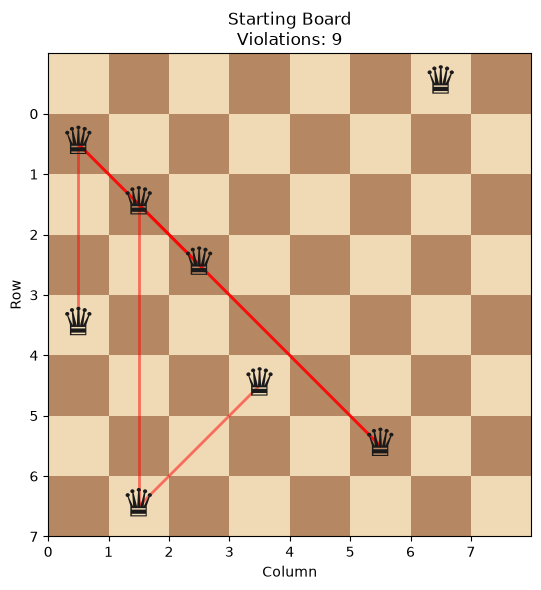


Final board: [6, 1, 7, 4, 0, 3, 5, 2]
Final violations: 1
Steps taken: 11


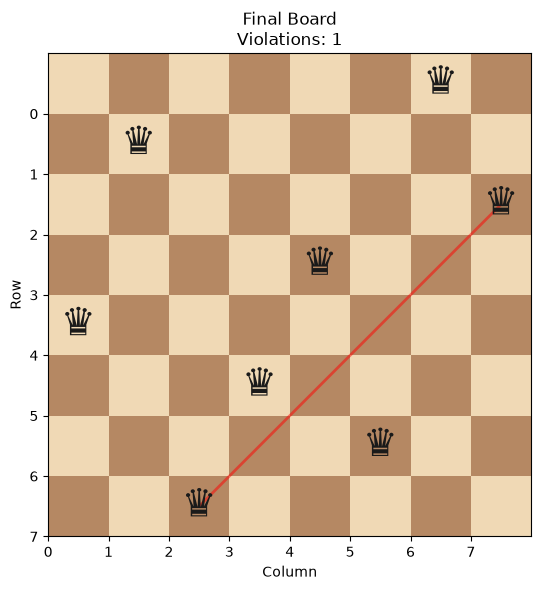

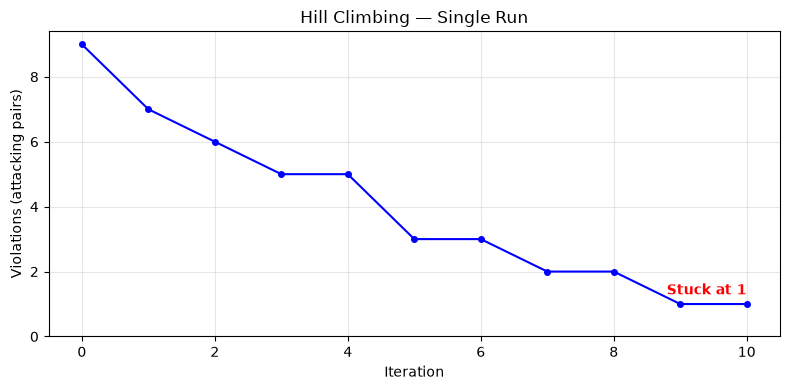

In [53]:
start_board = random_board()
print(f"Starting board: {start_board}")
print(f"Starting violations: {count_violations(start_board)}")
visualise_board(start_board, title="Starting Board")

final_board, log = hill_climbing(start_board)
print(f"\nFinal board: {final_board}")
print(f"Final violations: {count_violations(final_board)}")
print(f"Steps taken: {len(log)}")

visualise_board(final_board, title="Final Board")
plot_violations(log, title="Hill Climbing — Single Run")

**Did it solve the problem?** If violations reached 0, great, but try re-running the cell a few times. Each run starts from a different random board, so you'll see different outcomes.

> **Getting stuck is expected.** Hill climbing fails on 8-queens about 86% of the time. If your run got stuck at a non-zero violation count, your code is probably correct; Part 4 will confirm this by running many trials. The `max_steps` safety limit is 1000, but hill climbing on 8-queens typically finishes in under 10 steps; if your code takes 1000 steps, there's likely a bug.

---

## Part 4: Run 50 trials

Hill climbing is **not guaranteed** to find a solution. Run it 50 times with different random starting boards and see how many succeed.

In [54]:
num_trials = 50
solved = 0
stuck = 0
all_logs = []

for trial in range(num_trials):
    start = random_board()
    final, log = hill_climbing(start)
    final_v = count_violations(final)
    all_logs.append(log)

    status = "SOLVED" if final_v == 0 else f"STUCK (v={final_v})"
    if final_v == 0:
        solved += 1
    else:
        stuck += 1

    print(f"Trial {trial+1:2d}: {status:15s}  steps={len(log):3d}  "
          f"start_v={log[0]}  final_v={final_v}")

print(f"\n{'='*50}")
print(f"Solved: {solved}/{num_trials} ({100*solved/num_trials:.0f}%)")
print(f"Stuck:  {stuck}/{num_trials} ({100*stuck/num_trials:.0f}%)")

Trial  1: SOLVED           steps= 14  start_v=10  final_v=0
Trial  2: SOLVED           steps= 12  start_v=6  final_v=0
Trial  3: STUCK (v=1)      steps= 10  start_v=11  final_v=1
Trial  4: STUCK (v=2)      steps=  8  start_v=7  final_v=2
Trial  5: STUCK (v=1)      steps=  9  start_v=7  final_v=1
Trial  6: STUCK (v=1)      steps=  9  start_v=6  final_v=1
Trial  7: STUCK (v=2)      steps= 13  start_v=12  final_v=2
Trial  8: STUCK (v=1)      steps= 12  start_v=8  final_v=1
Trial  9: STUCK (v=2)      steps= 11  start_v=9  final_v=2
Trial 10: STUCK (v=2)      steps= 11  start_v=9  final_v=2
Trial 11: STUCK (v=1)      steps=  9  start_v=6  final_v=1
Trial 12: SOLVED           steps= 15  start_v=9  final_v=0
Trial 13: STUCK (v=1)      steps= 16  start_v=12  final_v=1
Trial 14: STUCK (v=1)      steps=  7  start_v=5  final_v=1
Trial 15: STUCK (v=2)      steps=  7  start_v=6  final_v=2
Trial 16: STUCK (v=3)      steps= 11  start_v=10  final_v=3
Trial 17: STUCK (v=1)      steps= 10  start_v=8  fi

### Visualise all runs

The plot below shows violations per iteration for all 50 runs. Green lines reached 0 (solved), red lines got stuck.

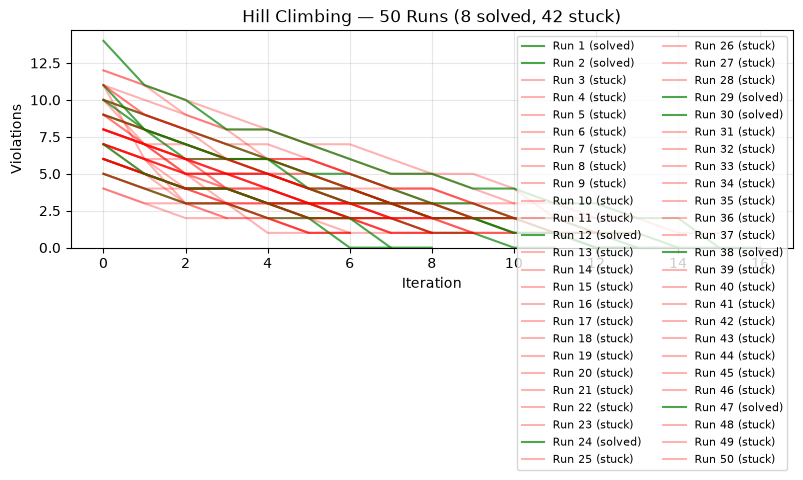

In [55]:
plot_multiple_runs(all_logs, title=f"Hill Climbing — {num_trials} Runs ({solved} solved, {stuck} stuck)")

---

## Part 5: Record your results

Fill in the table below (double-click this cell to edit).

| Metric | Value |
|--------|-------|
| Trials run | 50___ |
| Times solved (0 violations) | _7__ |
| Times stuck (local minimum) | __43_ |
| Success rate | 14___% |

**Answer these questions** (double-click to edit):

1. What fraction of runs solved the problem? Is this what you expected?
the ratio is only 14% which is very low

2. Look at a run that got stuck. What does the violations log look like at the end? Why can't the algorithm escape?

   becasue the neighbour violation is greater than current plate, and most of the plate is not solved but close to be solved

3. How is hill climbing different from BFS? When would you prefer each?

   hill climbing tend to find local minimum which means most of the time is close to the target but not met the target, however BFS can get to a target with the shortest path


In [56]:
from jupyterquiz import display_quiz

hc_quiz = [
    {
        "question": "What is a 'local minimum' in hill climbing?",
        "type": "multiple_choice",
        "answers": [
            {"answer": "A state where no neighbour is better, but the state is not a global solution.", "correct": True, "feedback": "Correct! The algorithm is stuck — every move makes things worse — but it hasn't found the best possible answer."},
            {"answer": "The starting point of the algorithm.", "correct": False, "feedback": "The starting point is usually random, not a local minimum."},
            {"answer": "The global best solution.", "correct": False, "feedback": "That's the global minimum. A local minimum is a point that's better than its neighbours but not necessarily the best overall."},
            {"answer": "A state with the most violations.", "correct": False, "feedback": "That would be a local maximum of violations. A local minimum has fewer violations than its neighbours."}
        ]
    },
    {
        "question": "Why does hill climbing often fail on 8-queens?",
        "type": "multiple_choice",
        "answers": [
            {"answer": "The search landscape has many local minima — the algorithm gets stuck in one and can't escape.", "correct": True, "feedback": "Correct! The 8-queens landscape is rugged. About 86% of random starts lead to a local minimum, not the global solution."},
            {"answer": "The algorithm is too slow to find a solution.", "correct": False, "feedback": "Hill climbing is actually very fast (usually under 10 steps). Speed isn't the problem — it's getting stuck."},
            {"answer": "The 8-queens problem has no solution.", "correct": False, "feedback": "8-queens has 92 distinct solutions! The problem is that hill climbing can't always find one."},
            {"answer": "The heuristic (violation count) is a bad measure.", "correct": False, "feedback": "The violation count is a perfectly good measure — 0 violations IS the goal. The problem is that the landscape created by this measure has local minima."}
        ]
    },
    {
        "question": "How could you improve hill climbing's success rate on 8-queens?",
        "type": "multiple_choice",
        "answers": [
            {"answer": "Random restarts — if you get stuck, start over with a new random board and try again.", "correct": True, "feedback": "Correct! With enough random restarts, you're very likely to eventually start in a position that leads to a solution. This is covered in the Credit task (C1)."},
            {"answer": "Use a bigger board (more queens).", "correct": False, "feedback": "A bigger board would make the problem harder, not easier."},
            {"answer": "Remove the violation check.", "correct": False, "feedback": "Without checking violations, the algorithm has no way to evaluate progress."},
            {"answer": "Always move to a random neighbour instead of the best one.", "correct": False, "feedback": "Random moves would just be a random walk — no progress toward a solution. Though adding a small amount of randomness (simulated annealing) can help."}
        ]
    }
]

display_quiz(hc_quiz, shuffle_answers=True)

<IPython.core.display.Javascript object>

---

## Part 6: Reflection — "Who is responsible when an algorithm fails?" (P4.2)

Write a short reflective response (150–250 words) to the question:

> *"Who is responsible when an algorithm fails?"*

Southwest Airlines' December 2022 collapse stranded hundreds of thousands of passengers. The scheduling algorithm couldn't recover from cascading disruptions. Who bears responsibility — the engineers who built it? The executives who didn't invest in upgrades? The regulators who didn't require resilience testing?

**Write your response in the cell below — it stays in this notebook.** You do not upload it as a separate file.

**P4.2 reflection — your response (150–250 words):**

*(Write your reflection here. Double-click this cell to edit. It stays in the notebook — do not upload it separately.)*

I think algorithm designers and company decision makers should take the most responsibility when an algorithm fails. Because it might not be the best algorithm in this situation and the designer doesn't capture the potential risk when applying this algorithm. Whereas for company decision makers, they aim for a view that might casus this issue, most of them imagine a function but lack analyzing the risk. As for  those executives, they might lack upgrading the system, then make this algorithm out of date. And for regulators, they might not capture every little case that might occur. In conclusion, I think if one algorithm fails, we should discuss it case by case. It is hard to determine if it is only one's fault. Since every part of building, maintaining and applying this algorithm, the problem will occur in any part of this chain.   

---

## Submission checklist

- [x ] P4.1: Hill climbing implementation working on 8-queens
- [x ] 50 runs with success/failure counts recorded (Part 4)
- [x ] Violations vs iteration plot (Part 4)
- [x ] Results table and reflection questions answered (Part 5)
- [x ] P4.2: Reflection on "Who is responsible when an algorithm fails?" (150–250 words, written in Part 6 of this notebook)
- [x ] Milestone discussion booked with tutor

**Uploading to OnTrack.** Submit **two things**: (1) this completed notebook, and (2) a **single** photo or PDF of your hand trace (P4.1). Your P4.2 reflection stays *inside this notebook* — OnTrack allows only one extra file besides the notebook, and that file is your hand trace.